### Finding 1: NAV Trend Analysis

The NAV trend shows long-term growth across selected mutual fund schemes from 2022 to 2026. The highlighted 2023 period indicates stronger upward movement, while 2024 shows visible correction and volatility phases.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

In [2]:
fund_master = pd.read_csv("data/processed/01_fund_master.csv")
nav_history = pd.read_csv("data/processed/02_nav_history.csv")
aum = pd.read_csv("data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/processed/04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv("data/processed/05_category_inflows.csv")
folios = pd.read_csv("data/processed/06_industry_folio_count.csv")
performance = pd.read_csv("data/processed/07_scheme_performance.csv")
transactions = pd.read_csv("data/processed/08_investor_transactions.csv")
holdings = pd.read_csv("data/processed/09_portfolio_holdings.csv")
benchmarks = pd.read_csv("data/processed/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
sip["month"] = pd.to_datetime(sip["month"])
category_inflows["month"] = pd.to_datetime(category_inflows["month"])
folios["month"] = pd.to_datetime(folios["month"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
holdings["portfolio_date"] = pd.to_datetime(holdings["portfolio_date"])
benchmarks["date"] = pd.to_datetime(benchmarks["date"])

print("Date conversion completed!")

Date conversion completed!


In [4]:
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


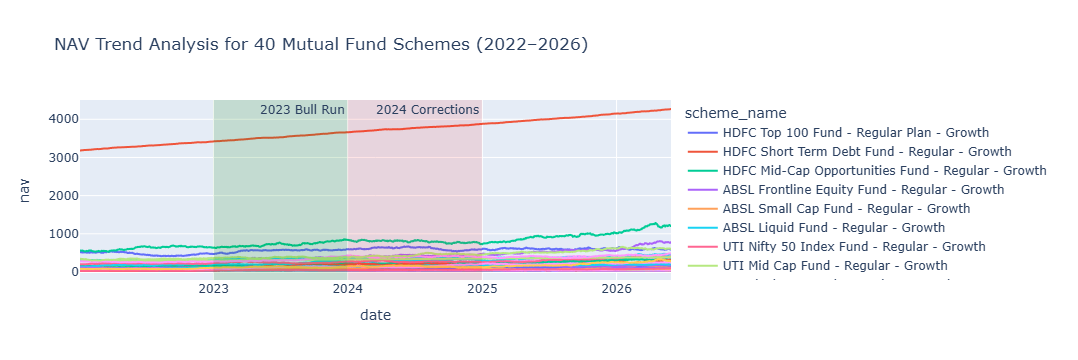

In [5]:
nav_merged = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

fig = px.line(
    nav_merged,
    x="date",
    y="nav",
    color="scheme_name",
    title="NAV Trend Analysis for 40 Mutual Fund Schemes (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Corrections"
)

fig.show()

In [6]:
from pathlib import Path

Path("reports/charts").mkdir(parents=True, exist_ok=True)

In [7]:
fig.write_html("reports/charts/nav_trend_analysis.html")

In [8]:
import os
print(os.listdir("reports/charts"))

['nav_trend_analysis.html']


In [14]:
fig.write_image("reports/charts/nav_trend_analysis.png")

Resorting to unclean kill browser.


In [12]:
fig.write_image("reports/charts/nav_trend_analysis.png")

Resorting to unclean kill browser.


### Finding 2: AUM Growth Analysis

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among the selected fund houses. The chart shows steady industry-wide AUM growth from 2022 onwards, reflecting increased investor participation in mutual funds.

In [15]:
print(aum.columns.tolist())
print(aum.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [16]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


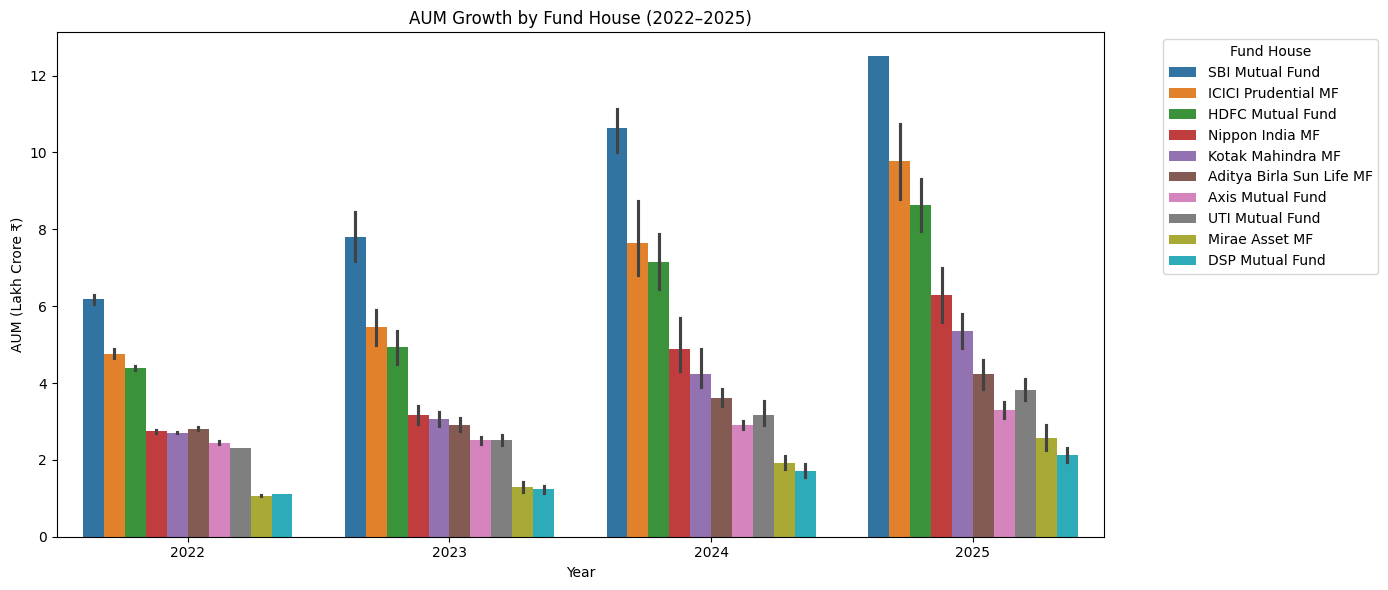

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [19]:
plt.savefig(
    "reports/charts/aum_growth_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [20]:
import os
print(os.listdir("reports/charts"))

['aum_growth_analysis.png', 'nav_trend_analysis.html', 'nav_trend_analysis.png']


### Finding 3: SIP Inflow Growth

Monthly SIP inflows increased strongly from 2022 to 2025, reaching an all-time high of ₹31,002 crore in December 2025. This indicates rising investor confidence and stronger retail participation through SIPs.

In [21]:
print(sip.columns.tolist())
print(sip.head())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   
3 2022-04-01             11863                       5.48   
4 2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


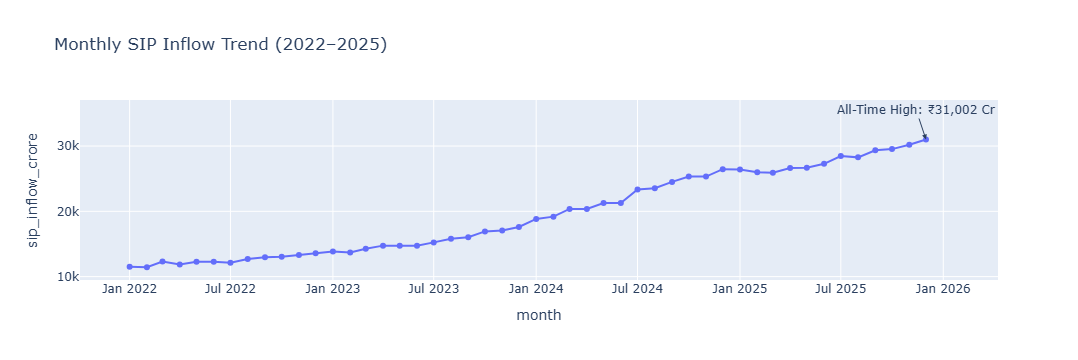

In [26]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

# Find highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=str(max_row["month"].date()),
    y=float(max_row["sip_inflow_crore"]),
    text=f"All-Time High: ₹{int(max_row['sip_inflow_crore']):,} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [27]:
fig.write_html("reports/charts/sip_inflow_trend.html")

In [28]:
fig.write_image("reports/charts/sip_inflow_trend.png")

Resorting to unclean kill browser.


In [29]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

### Finding 4: Category Inflow Distribution

Flexi Cap, Mid Cap, and Large & Mid Cap categories consistently attracted higher inflows compared to other categories. Investor preference remained concentrated in diversified equity-oriented schemes.

In [30]:
print(category_inflows.columns.tolist())
print(category_inflows.head())

['month', 'category', 'net_inflow_crore']
       month         category  net_inflow_crore
0 2024-04-01        Large Cap              2413
1 2024-04-01          Mid Cap              3897
2 2024-04-01        Small Cap              3533
3 2024-04-01        Flexi Cap              4947
4 2024-04-01  Large & Mid Cap              4214


In [31]:
heatmap_data = category_inflows.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466,553,472,471,499,537,537,571,521,516,437,500
Flexi Cap,4947,5529,4478,4869,5562,5397,6004,6111,4654,5603,6068,4767
Gilt,784,836,864,959,952,925,898,704,831,744,942,956
Hybrid,2955,3487,3163,3291,3684,3015,3314,3264,3538,2967,3360,2830
Large & Mid Cap,4214,4368,4610,5023,5411,4528,4581,5556,4878,4816,5524,4243


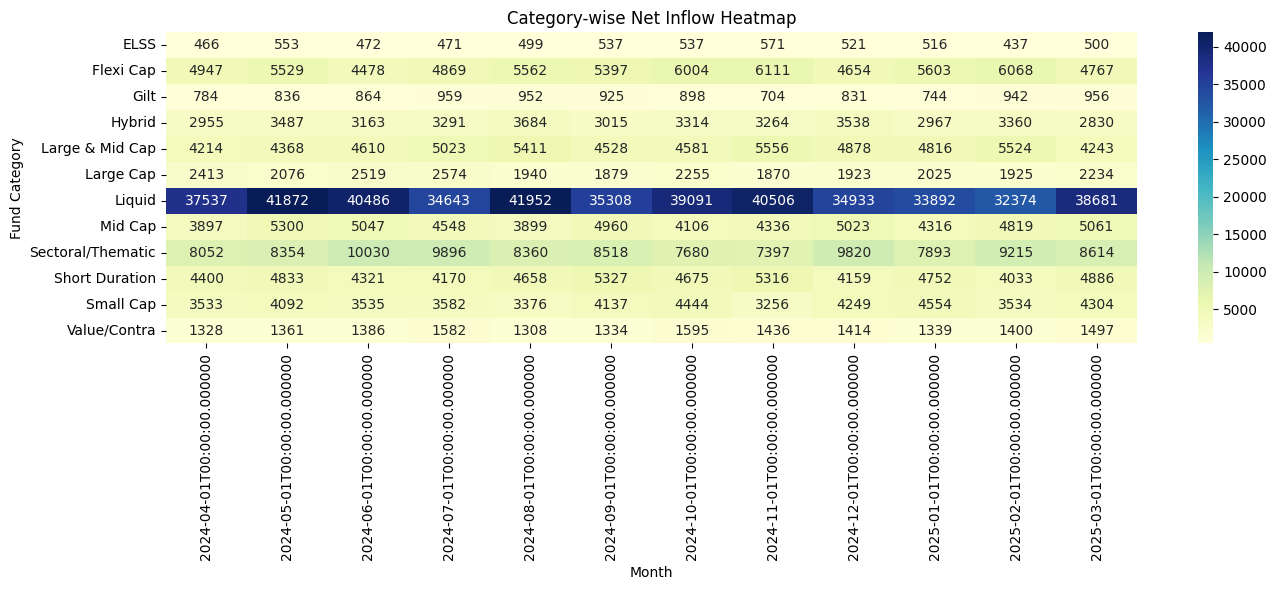

In [32]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

In [33]:
plt.savefig(
    "reports/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Finding 5: Age Group Distribution

The majority of mutual fund investors belong to the working-age population, particularly the 26–45 age groups, indicating strong participation from salaried and mid-career professionals.

In [34]:
print(transactions.columns.tolist())
print(transactions.head())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female      

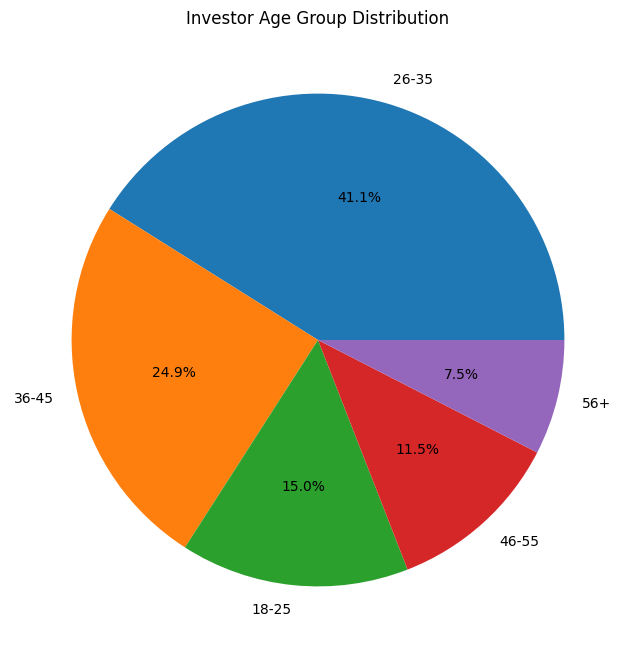

In [35]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 6: SIP Investment Behaviour

Higher age groups generally show larger SIP investments, reflecting increased earning capacity and long-term wealth accumulation strategies.

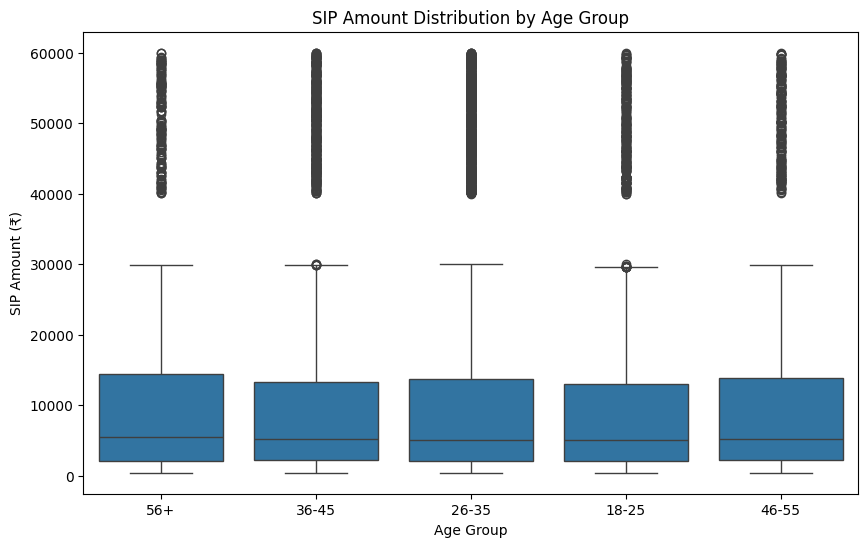

In [36]:
sip_txn = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.savefig(
    "reports/charts/sip_boxplot_agegroup.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 7: Gender Participation

Male investors constitute a larger share of mutual fund transactions, though female participation remains significant and continues to grow.

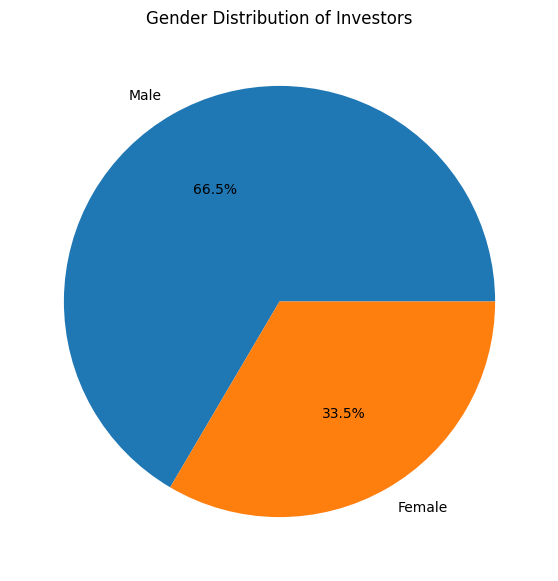

In [37]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 8: Geographic Distribution

A small number of states contribute a significant share of total mutual fund investments, indicating concentration of investment activity in economically stronger regions.

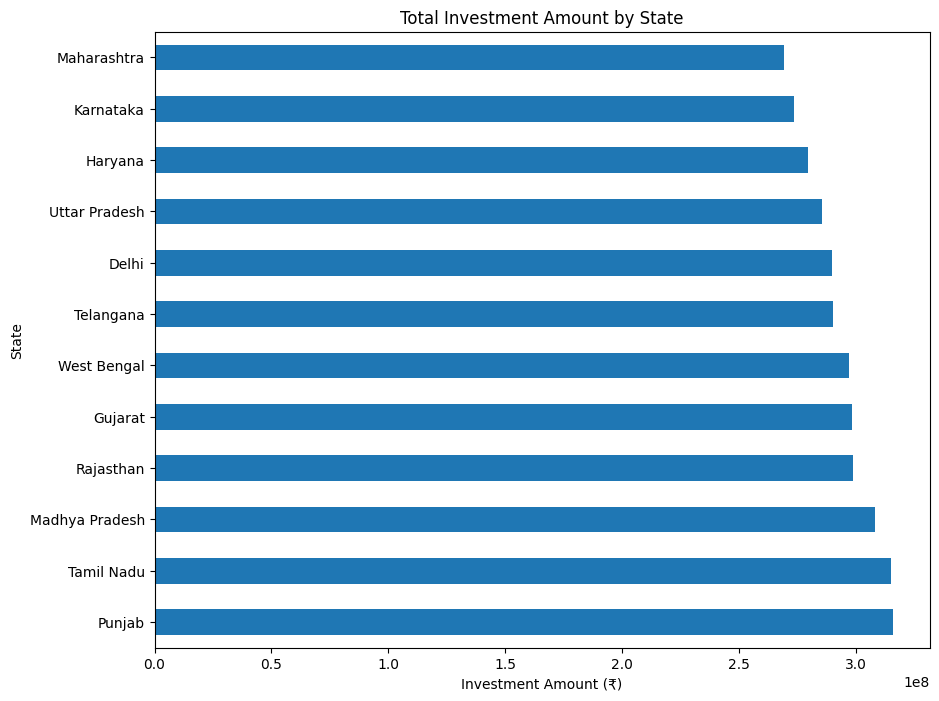

In [38]:
state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

state_sip.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.savefig(
    "reports/charts/state_wise_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 9: City Tier Participation

T30 cities account for the majority of mutual fund participation, though B30 cities represent an increasingly important source of future investor growth.

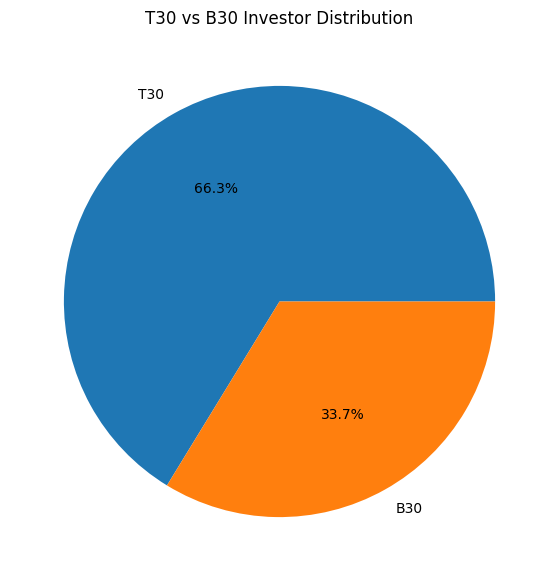

In [39]:
city_tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 10: Folio Growth

Total mutual fund folios increased significantly from 2022 to 2025, reflecting growing investor awareness, financial inclusion, and participation in capital markets.

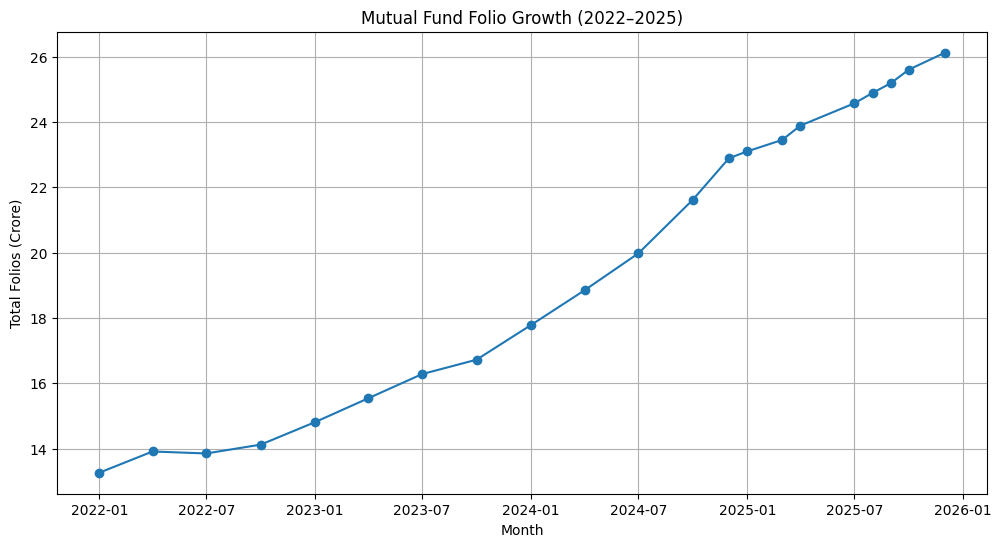

In [40]:
plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.savefig(
    "reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 11: Fund Correlation Analysis

Most mutual funds exhibit positive return correlations, indicating that market-wide movements influence fund performance. However, correlation strengths vary across categories, highlighting diversification opportunities.

In [41]:
print(nav_history.columns.tolist())
print(nav_history.head())

['amfi_code', 'date', 'nav']
   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [44]:
top10_codes = nav_history["amfi_code"].unique()[:10]

nav_subset = nav_history[
    nav_history["amfi_code"].isin(top10_codes)
]

In [43]:
nav_pivot = nav_subset.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [45]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [46]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


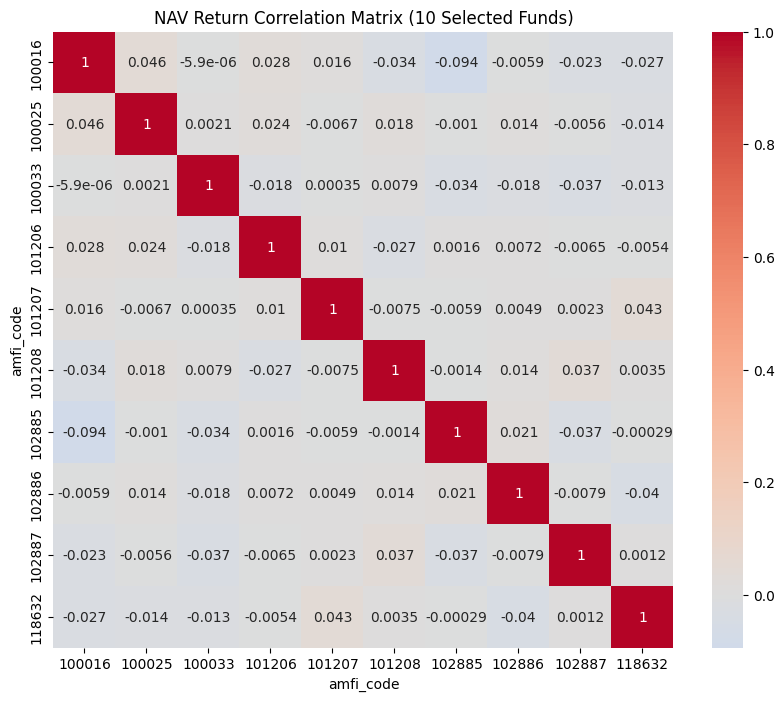

In [47]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix (10 Selected Funds)")

plt.savefig(
    "reports/charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 12: Sector Allocation

Banking, IT, Pharma, and Financial Services sectors account for a significant share of mutual fund portfolios, indicating their importance in diversified equity fund strategies.

In [48]:
print(holdings.columns.tolist())


['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [49]:
sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data.head(10)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

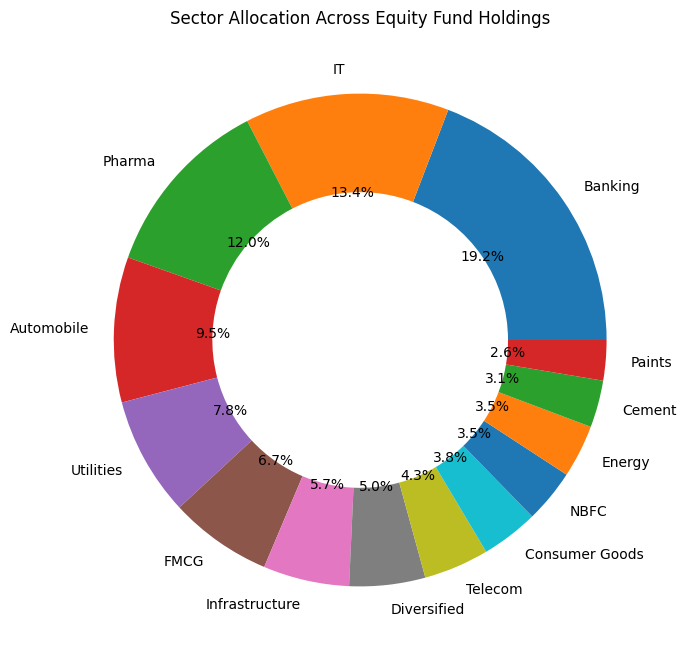

In [50]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Fund Holdings")

plt.savefig(
    "reports/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 13: Largest Funds by Assets

A small number of large-cap and diversified schemes dominate industry assets, reflecting strong investor preference for established funds.

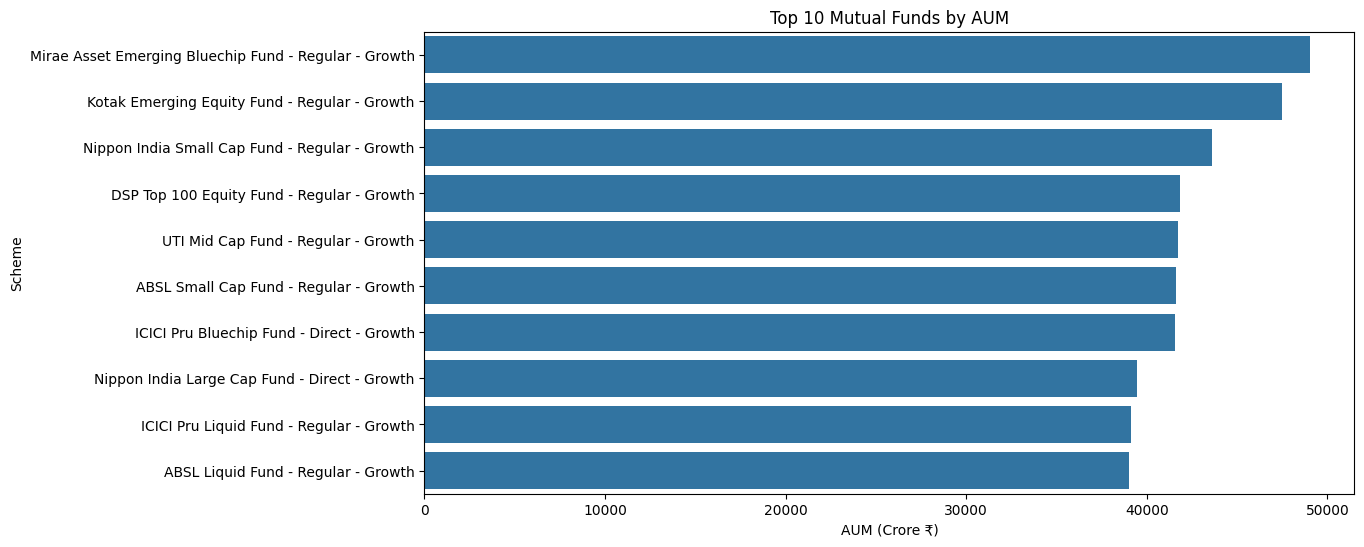

In [51]:
top_funds = performance.sort_values(
    "aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by AUM")
plt.xlabel("AUM (Crore ₹)")
plt.ylabel("Scheme")

plt.savefig(
    "reports/charts/top10_funds_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 14: Risk Profile

Most schemes fall into moderate-to-high risk categories, reflecting the dominance of equity-oriented mutual fund products.

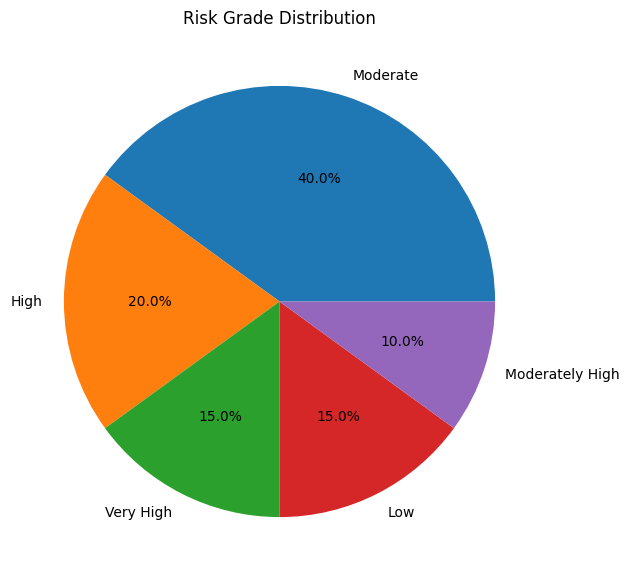

In [52]:
risk_counts = performance["risk_grade"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%"
)

plt.title("Risk Grade Distribution")

plt.savefig(
    "reports/charts/risk_grade_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 15: Transaction Behaviour

SIP transactions constitute a major portion of investor activity, highlighting the popularity of systematic investing over one-time investments.

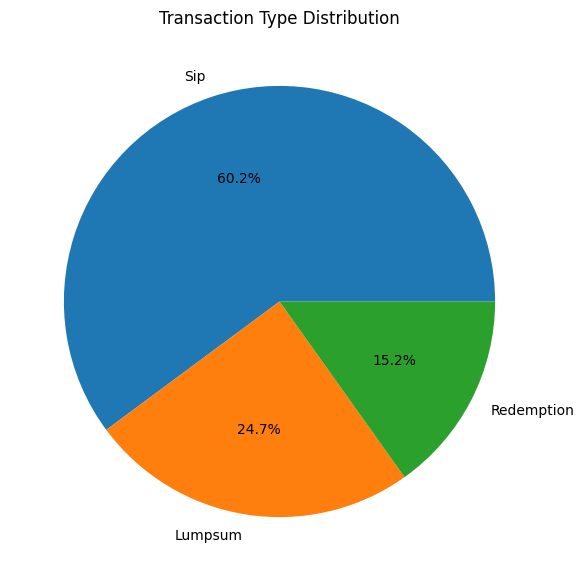

In [53]:
txn_counts = transactions["transaction_type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    txn_counts,
    labels=txn_counts.index,
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")

plt.savefig(
    "reports/charts/transaction_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()